# Análisis de Evasión de Clientes (Churn) – Telecom X

## Contexto
La empresa Telecom X enfrenta un alto nivel de cancelación de clientes. Este fenómeno, conocido como **Churn**, representa un desafío importante para el negocio, ya que implica pérdida de ingresos y mayores costos de adquisición de nuevos clientes.

## Objetivo del análisis
El objetivo de este proyecto es analizar los datos de clientes para identificar patrones asociados con la evasión y comprender qué factores pueden influir en la decisión de cancelar el servicio.

Para ello se realizó un proceso de:
- Extracción de datos
- Transformación y limpieza
- Análisis exploratorio
- Generación de insights y recomendaciones

#📌 Extracción

####En esta etapa se realizó la obtención de los datos de Telecom X. Los datos fueron cargados desde el archivo JSON y convertidos a un DataFrame de pandas para facilitar su manipulación y análisis.

In [6]:
import pandas as pd

df = pd.read_json("/content/TelecomX_Data.json")
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [7]:
with open("/content/TelecomX_diccionario.md", "r") as f:
    print(f.read())

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: t

#🔧 Transformación

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


### Corrección de inconsistencias

Tras la revisión de la calidad de los datos, no se identificaron valores ausentes en el dataset. Sin embargo, se observó que varias columnas (`customer`, `phone`, `internet` y `account`) contienen estructuras anidadas.



In [10]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

In [11]:
df_final = pd.concat(
    [df[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [12]:
df_final["Cuentas_Diarias"] = df_final["Charges.Monthly"] / 30

In [13]:
df_final[["Charges.Monthly","Cuentas_Diarias"]].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


Se creó la columna **Cuentas_Diarias** a partir de la facturación mensual (`Charges.Monthly`), dividiendo su valor por 30. Esta nueva variable permite estimar el gasto diario de cada cliente y aporta una visión más detallada para el análisis.

In [14]:
cols_binarias = [
    "Partner","Dependents","PhoneService","PaperlessBilling",
    "OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies","MultipleLines"
]

df_final[cols_binarias] = df_final[cols_binarias].replace({"Yes":1, "No":0})

/tmp/ipykernel_963/51232446.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final[cols_binarias] = df_final[cols_binarias].replace({"Yes":1, "No":0})


In [15]:
df_final[cols_binarias].head()

,Partner,Dependents,PhoneService,PaperlessBilling,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,1,1,1,1,0,1,0,1,1,0,0
1,0,0,1,0,0,0,0,0,0,1,1
2,0,0,1,1,0,0,1,0,0,0,0
3,1,0,1,1,0,1,1,0,1,1,0
4,1,0,1,1,0,0,0,1,1,0,0


Se estandarizaron variables categóricas que contenían valores Yes/No, convirtiéndolas a 1 y 0 para facilitar el análisis y el procesamiento de los datos.

#📊 Carga y análisis

In [16]:
df_final.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2.157337
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,1.180833
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,2.343333
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,2.995833
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,3.958333


Se realizó un análisis descriptivo del dataset utilizando la función `describe()` de pandas.  
Esto permitió observar métricas estadísticas como media, desviación estándar, valores mínimos y máximos, así como percentiles que ayudan a comprender la distribución de las variables y el comportamiento general de los clientes.

### Distribución de Churn
Visualización de la proporción de clientes que permanecen en la empresa frente a aquellos que cancelaron el servicio.

In [18]:
df_final["Churn"] = df_final["Churn"].replace({1: "Canceló", 0: "Permanece"})

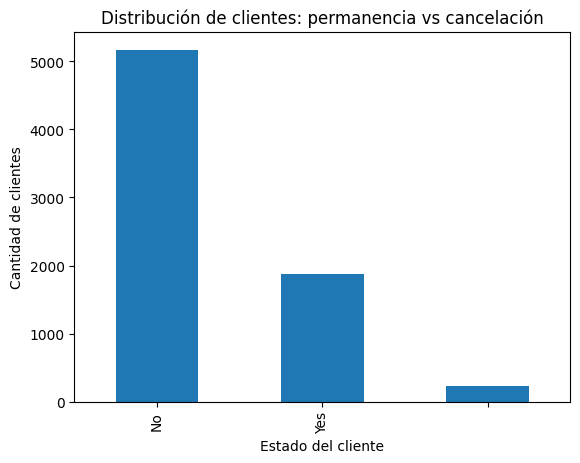

In [19]:
df_final["Churn"].value_counts().plot(kind="bar")
plt.title("Distribución de clientes: permanencia vs cancelación")
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad de clientes")
plt.show()

Los contratos mensuales tienden a presentar una mayor tasa de cancelación en comparación con los contratos de mayor duración.

### Churn según género
Comparación de la evasión de clientes entre hombres y mujeres.

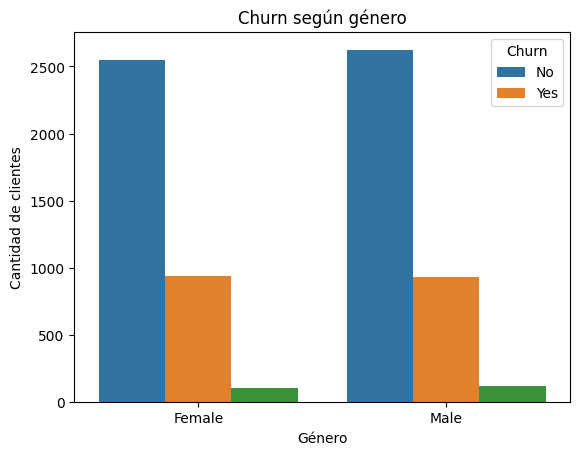

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_final, x="gender", hue="Churn")

plt.title("Churn según género")
plt.xlabel("Género")
plt.ylabel("Cantidad de clientes")

plt.show()

Se analizó la distribución de la evasión de clientes según el género.  
Esta visualización permite identificar si existe alguna diferencia en la tasa de cancelación entre hombres y mujeres.

### Churn según tipo de contrato
Análisis de la relación entre el tipo de contrato y la cancelación del servicio.

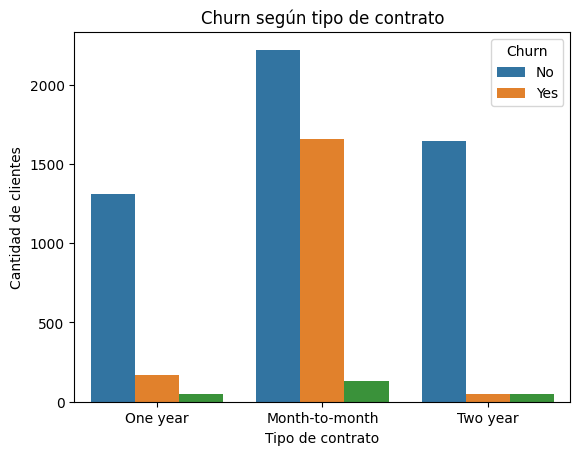

In [24]:
sns.countplot(data=df_final, x="Contract", hue="Churn")

plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.show()

Los contratos mensuales tienden a presentar una mayor tasa de cancelación en comparación con los contratos de mayor duración.

### Tiempo de permanencia vs Churn
Análisis del tiempo de permanencia de los clientes en relación con la evasión.

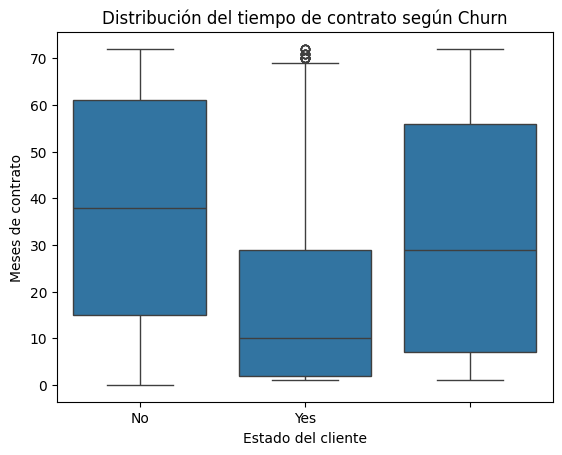

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_final, x="Churn", y="tenure")

plt.title("Distribución del tiempo de contrato según Churn")
plt.xlabel("Estado del cliente")
plt.ylabel("Meses de contrato")

plt.show()

Se analizó la distribución del tiempo de contrato (`tenure`) en relación con la evasión de clientes. Este análisis permite observar si los clientes con menor antigüedad presentan mayor tendencia a cancelar el servicio.

#📄Informe final


#  Análisis de Churn

## Introducción
El objetivo de este análisis fue comprender los factores asociados a la evasión de clientes (Churn) en Telecom X. Identificar estos patrones permite a la empresa mejorar sus estrategias de retención y reducir la cancelación de servicios.

## Limpieza y tratamiento de datos
Los datos fueron cargados desde un archivo JSON y transformados en un DataFrame de pandas.  
Se normalizaron columnas anidadas, se verificaron valores nulos y se crearon nuevas variables como **Cuentas_Diarias** para facilitar el análisis.

## Análisis exploratorio
Se analizaron variables categóricas y numéricas mediante visualizaciones.  
Los gráficos permitieron observar la distribución del churn, su relación con el tipo de contrato, el género y el tiempo de permanencia de los clientes.

## Conclusiones y recomendaciones
Los resultados muestran que los clientes con **contratos mensuales** y **menor tiempo de permanencia** presentan mayor probabilidad de cancelación.  

Para reducir el churn se recomienda:
- Incentivar contratos de mayor duración.
- Implementar estrategias de fidelización para clientes nuevos.
- Ofrecer paquetes de servicios que aumenten el valor percibido por el cliente.

#🔧 EXTRA

In [22]:
df_final.corr(numeric_only=True)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Cuentas_Diarias
SeniorCitizen,1.000000,0.022970,-0.212952,0.018187,0.010060,0.157734,0.220388,0.220388
Partner,0.022970,1.000000,0.448900,0.377551,0.018828,-0.011201,0.097122,0.097122
Dependents,-0.212952,0.448900,1.000000,0.159892,-0.003863,-0.111752,-0.115832,-0.115832
tenure,0.018187,0.377551,0.159892,1.000000,0.010205,0.007949,0.247982,0.247982
PhoneService,0.010060,0.018828,-0.003863,0.010205,1.000000,0.013624,0.246709,0.246709
PaperlessBilling,0.157734,-0.011201,-0.111752,0.007949,0.013624,1.000000,0.353714,0.353714
Charges.Monthly,0.220388,0.097122,-0.115832,0.247982,0.246709,0.353714,1.000000,1.000000
Cuentas_Diarias,0.220388,0.097122,-0.115832,0.247982,0.246709,0.353714,1.000000,1.000000


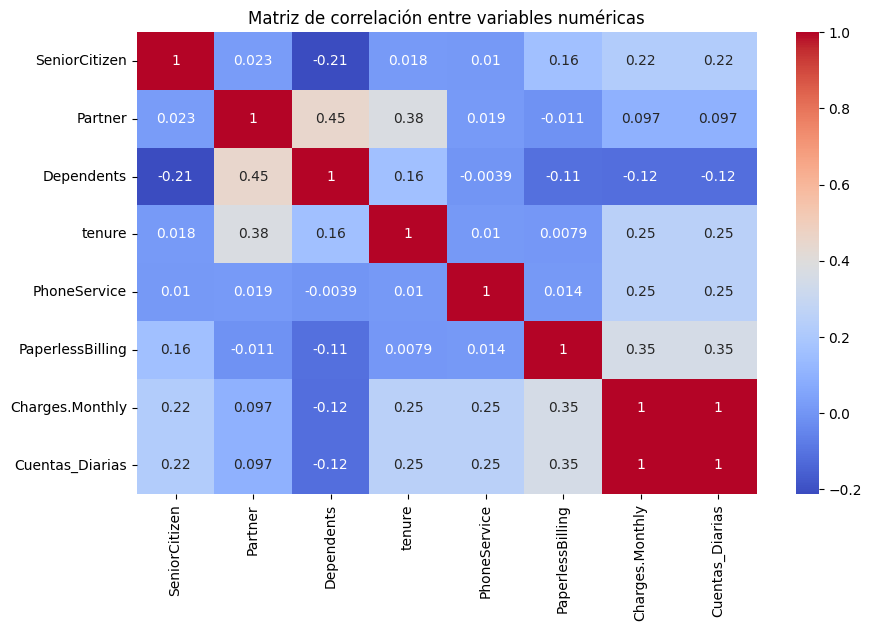

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df_final.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

### Análisis de correlación

Como análisis adicional, se exploró la correlación entre variables numéricas del dataset utilizando la función `corr()` de pandas.

La matriz de correlación permite identificar qué variables tienen mayor relación entre sí y cuáles podrían influir en la evasión de clientes (Churn). Este tipo de análisis es útil como paso previo para la construcción de modelos predictivos.